# Clinical Risk Prediction for Heart Disease
## Exploratory Data Analysis & Preprocessing

**Dataset**: UCI Heart Failure Clinical Records (ID 519) — 299 patients, 12 clinical features  
**Target**: `death_event` — binary outcome (0 = survived, 1 = died during follow-up)  
**Class balance**: ~68% survived / ~32% died (imbalanced)

### Objective

This notebook performs exploratory data analysis prior to statistical inference and modeling. The goals are:

1. Understand the structure and quality of the data
2. Describe the univariate distributions of all features
3. Detect and evaluate outliers against clinical reference ranges
4. Assess skewness and identify candidates for log/sqrt transformation
5. Explore bivariate relationships between features and the target

### Outputs

- Data is clean: no missing values
- All values are within normal medical ranges
- Some features may need transformation: `log1p` for `serum_creatinine` and `creatinine_phosphokinase`
- Early signs of useful features: They will be tested in Notebook 02 (Statistical Analysis)

# Table of Contents

- [1. Data Understanding](#1-data-understanding)
  - [1.1 Feature Information](#11-feature-information)
  - [1.2 Feature Description](#12-feature-description)
  - [1.3 Data Formatting](#13-data-formatting)
  - [1.4 Target Distribution](#14-target-distribution)

- [2. Data Exploration](#2-data-exploration)
  - [2.1 Univariate Distributions](#21-univariate-distributions)
    - [2.1.1 Numeric Distributions](#211-numeric-distributions)
    - [2.1.2 Outlier Analysis](#212-outlier-analysis)
    - [2.1.2.1 Clinical Validation](#2121-clinical-validation)
    - [2.1.4 Skewness & Transformations](#214-skewness--transformations)
    - [2.1.5 Categorical Variables](#215-categorical-variables)
  - [2.2 Bivariate Distribution](#22-bivariate-distribution)

In [2]:
# -----  Imports -------- #

# Sytem
import sys
from pathlib import Path

# Data cleaning
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# Own functions
sys.path.append(str(Path.cwd().parent / "src"))
from clinical_risk.plotting import (plot_grid,
                                    plot_countplot,
                                    plot_boxplot,
                                    plot_histogram,
                                    plot_clinical_boxplot)

from clinical_risk.descriptive import (iqr_outlier_summary,
                                        compare_skew)

# 1 Data Understanding

## 1.1 feature information

In [14]:
# fetch dataset 
data = fetch_ucirepo(id=519)

# variable infor
print(data.metadata.additional_info.variable_info)

Thirteen (13) clinical features:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- creatinine phosphokinase  (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction  (percentage)
- high blood pressure: if the patient has hypertension (boolean)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- [target] death event: if the patient died during the follow-up period (boolean)

For more information, please check Table 1, Table 2, and Table 3 of the following paper: 

Davide Chicco, Giuseppe Jurman: "Machine learning can predict survival of patients with heart failure from serum cr

## 1.2 feature description

In [4]:
X = data.data.features
y = data.data.targets

# Check data .info()
df = pd.concat([y, X ], axis=1)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 28.2 KB


In [5]:
X.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
dtype: int64

In [6]:
n_duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {n_duplicates}")

Número de filas duplicadas: 0


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percentage = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_df

,missing_count,missing_percentage
death_event,0,0.0
age,0,0.0
anaemia,0,0.0
creatinine_phosphokinase,0,0.0
diabetes,0,0.0
ejection_fraction,0,0.0
high_blood_pressure,0,0.0
platelets,0,0.0
serum_creatinine,0,0.0
serum_sodium,0,0.0


### Data Quality Summary

The dataset is clean: **no missing values, no duplicates** across all 13 columns (12 features + target).

- 5 of the integer variables are binary flags (anaemia, diabetes, high_blood_pressure, sex, smoking) → cast to `category` in section 1.3
- The remaining 4 integer variables (creatinine_phosphokinase, ejection_fraction, serum_sodium, time) are treated as numeric

**Implication**: no imputation strategy is required

## 1.3 Data Formatting

In [8]:
cat_cols = [ "sex","smoking","diabetes","high_blood_pressure","anaemia"]
df[cat_cols] = df[cat_cols].astype("category")


target = "death_event"
categorical_cols  = df.select_dtypes(include=["category"]).columns
numerical_cols = df.select_dtypes(include="number").columns.tolist()

In [9]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
death_event,299.0,0.321070,0.467670,0.0,0.0,0.0,1.0,1.0
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
time,299.0,130.260870,77.614208,4.0,73.0,115.0,203.0,285.0


In [10]:
df[categorical_cols].describe().T

,count,unique,top,freq
anaemia,299,2,0,170
diabetes,299,2,0,174
high_blood_pressure,299,2,0,194
sex,299,2,1,194
smoking,299,2,0,203


## 1.4 Target Distribution

In [13]:
summary = pd.DataFrame({
    "Count": y.value_counts(),
    "Proportion (%)": (y.value_counts(normalize=True) * 100).round(2)
}).sort_index()

display(summary)

,Count,Proportion (%)
death_event,,
0,203,67.89
1,96,32.11


### **Target summary**

Class balance in ~68% survived / ~32% died. Light imbalance

**Implication**
- The dataset shows a slight class imbalance, so SMOTE is not required  
- A stratified split and class weighting will be applied  
- A logistic regression model is used for coefficient interpretability  
- As an alternative, more robust models to class imbalance such as Random Forest or XGBoost could be considered  

# 2. Data Exploration

## 2.1 Univariate Distributions

### 2.1.1 Numeric Distributions

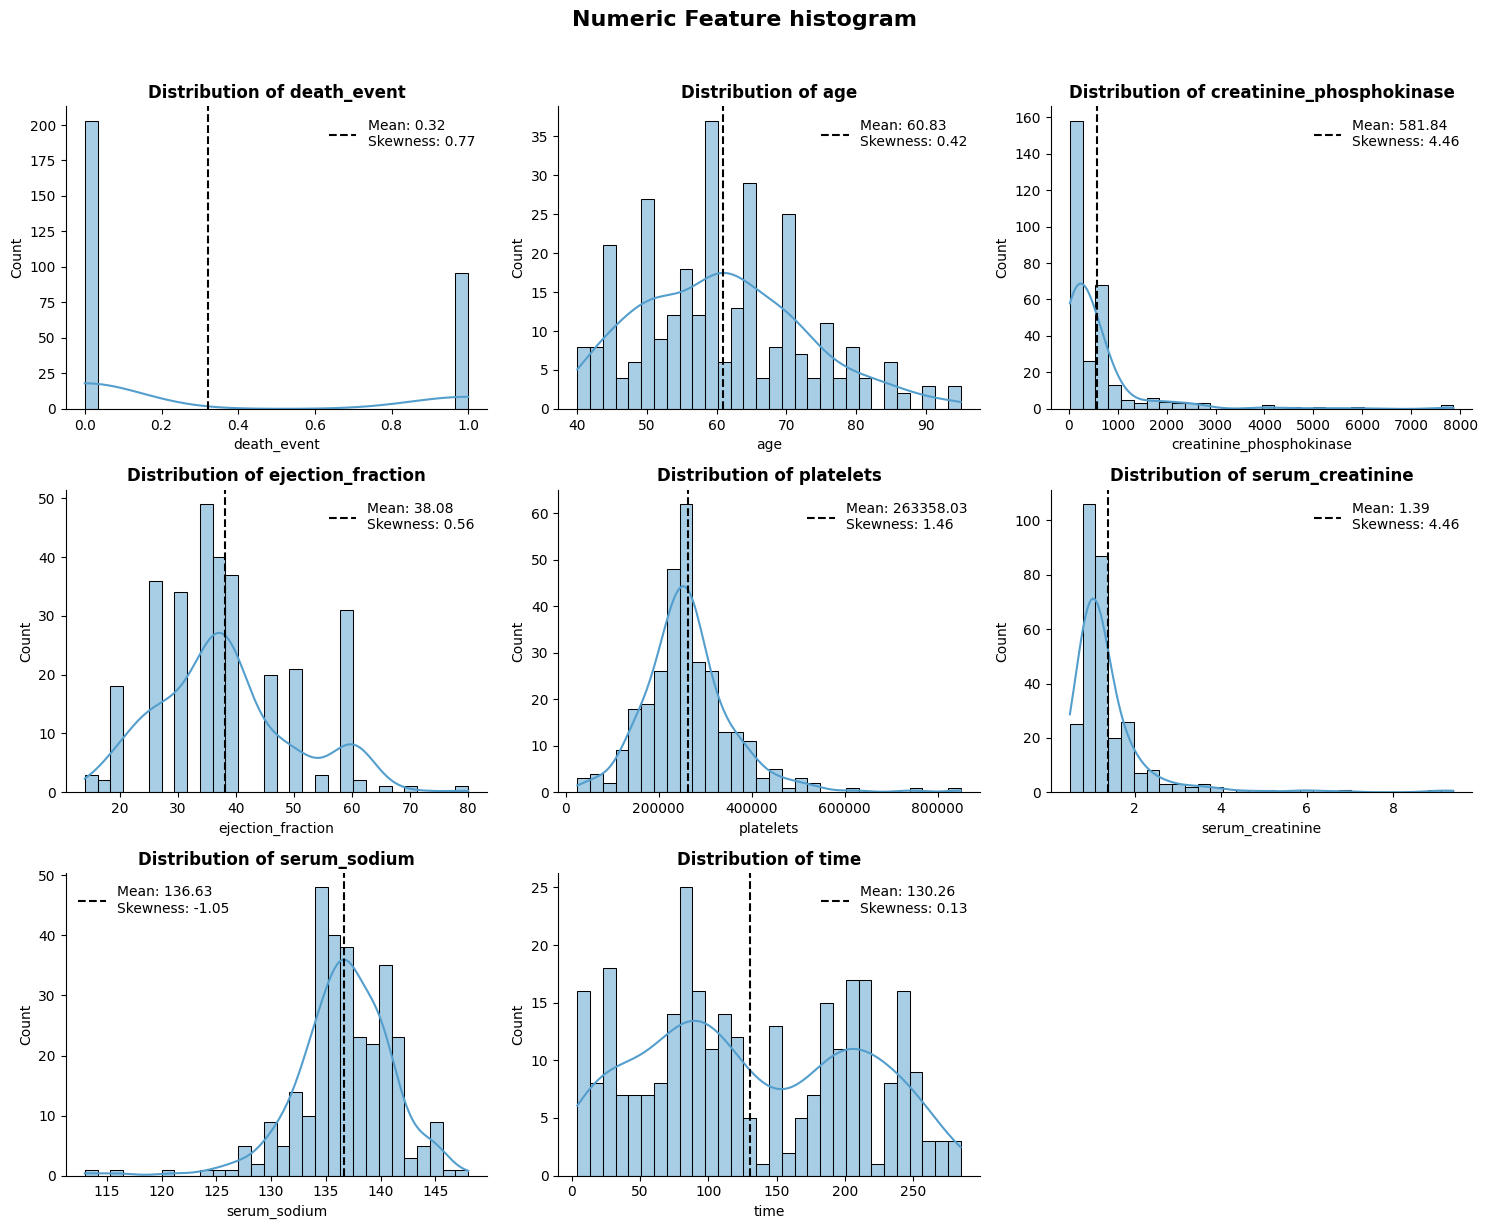

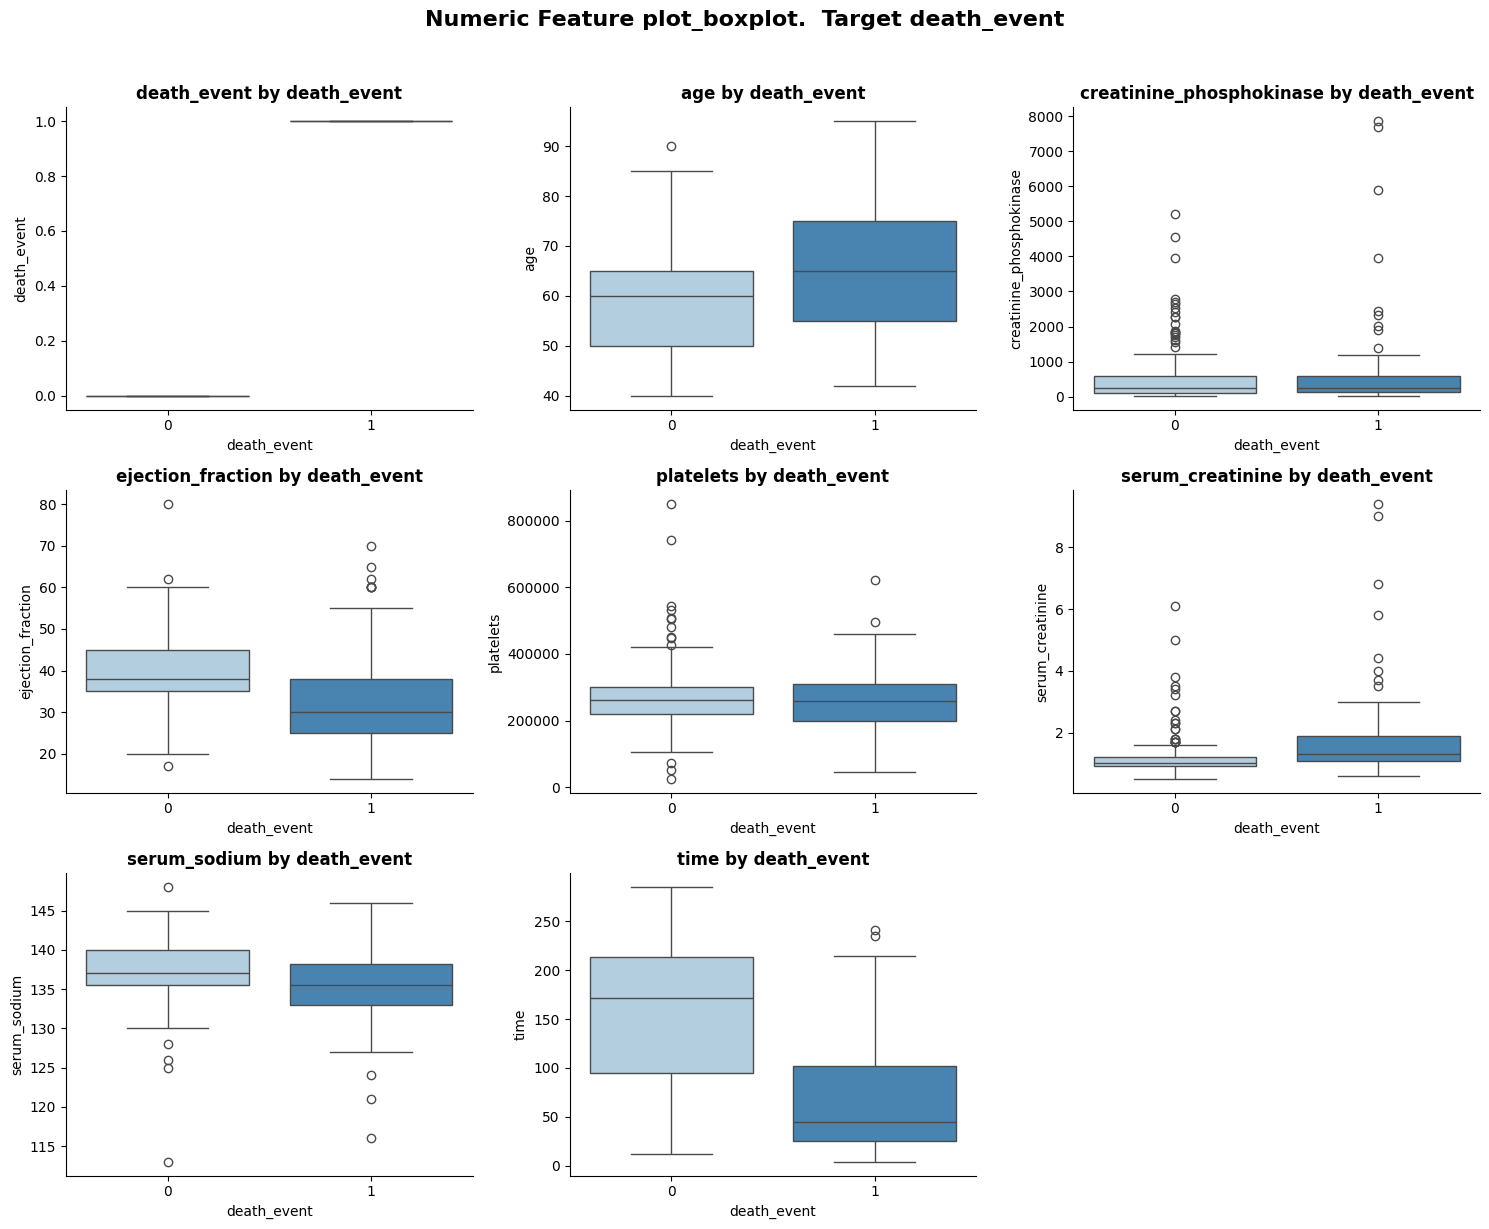

In [12]:
#Get histogram distribution
plot_grid(
    df=df,
    columns=numerical_cols,
    plot_func= plot_histogram,
    title="Numeric Feature histogram")


#Get boxplot distribution
plot_grid(
    df=df,
    columns=numerical_cols,
    plot_func= plot_boxplot,
    title="Numeric Feature plot_boxplot.  Target death_event",
    target = "death_event")

### Observations — Numeric Distributions

- **`creatinine_phosphokinase`** and **`serum_creatinine`**: show a strong right-skewed distribution, with some extremely high values. Patients who died tend to have higher median levels. A log transformation is considered
- **`time`** (follow-up period): It shows the clearest separation between outcome groups, but this reflects its definition as a follow-up variable rather than a true predictive feature. It should not be used as a predictor in a classification model due to data leakage.
- **`ejection_fraction`**: the death group skews lower (reduced cardiac output), consistent with heart failure severity.
- **`serum_sodium`**: death group shows slightly lower values, consistent with hyponatraemia* in decompensated heart failure.
- **`age`** and **`platelets`**: distributions show more overlap between outcome groups — weaker individual discriminators. However, it does not mean that they could not have contributions in combination with others features

**Notes:**
- The scale of numerical features varies considerably. Since Logistic Regression is sensitive to feature scale, the data will be standardized to ensure stable and comparable coefficient estimation

- Hyponatremia (serum sodium <135 mEq/L) is a common disorder in heart failure (HF) that acts as an independent marker of increased mortality.

### 2.1.2 Outlier Analysis

In [15]:
#Get iqr and outlier proportions
outlier_summary = iqr_outlier_summary(df, numerical_cols)


# Find outliers based on iqr to study
limits = outlier_summary.set_index("variable")[["lower_bound","upper_bound"]].to_dict("index")
mask = pd.Series(True, index=df.index)
for col, lim in limits.items():
    mask &= df[col].between(lim["lower_bound"], lim["upper_bound"])

invalid_rows = df[~mask]
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,n_outliers,outlier_pct
2,creatinine_phosphokinase,116.5,582.0,465.5,-581.75,1280.25,29,9.698997
5,serum_creatinine,0.9,1.4,0.5,0.15,2.15,29,9.698997
4,platelets,212500.0,303500.0,91000.0,76000.00,440000.00,21,7.023411
6,serum_sodium,134.0,140.0,6.0,125.00,149.00,4,1.337793
3,ejection_fraction,30.0,45.0,15.0,7.50,67.50,2,0.668896
1,age,51.0,70.0,19.0,22.50,98.50,0,0.000000
0,death_event,0.0,1.0,1.0,-1.50,2.50,0,0.000000
7,time,73.0,203.0,130.0,-122.00,398.00,0,0.000000


#### 2.1.2.1 Clinical Validation

* Laboratory reference ranges:

| Parameter | Reference Range | Extreme (Clinically Possible) | Impossible / Data Error |
| --- | --- | --- | --- |
| **Serum creatinine (mg/dL)** | 0.6 – 1.3 | 5 – 20 (severe renal failure) | <0 or >40 |
| **Serum sodium (mEq/L)** | 135 – 145 | 110 – 160 (severe electrolyte imbalance) | <90 or >200 |
| **Platelets (×10³/µL)** | 150 – 450 | 10 – 1000 (severe thrombocytopenia / thrombocytosis) | <0 or >2000 |
| **Ejection fraction (%)** | 50 – 70 | 10 – 80 (severe heart failure or hyperdynamic state) | <0 or >100 |
| **CPK (mcg/L)**  | ~20 – 200       | 200 – 10000+ (e.g., myocardial injury, muscle damage, rhabdomyolysis) | Negative values, or implausibly high values without clinical context (e.g., >100,000, very unlikely) |


* Cleaning boundaries: physiologically plausible limits used for data validation

| Parameter | Lower Bound | Upper Bound | Units |
| --- | --- | --- | --- |
| Serum creatinine | 0.1 | 20 | mg/dL |
| Serum sodium | 110 | 160 | mEq/L |
| Platelets | 10 | 1000 | ×10³/µL |
| Ejection fraction | 5 | 90 | % |
| Creatinine phosphokinase (CPK) | 10 | 100000 | U/L |

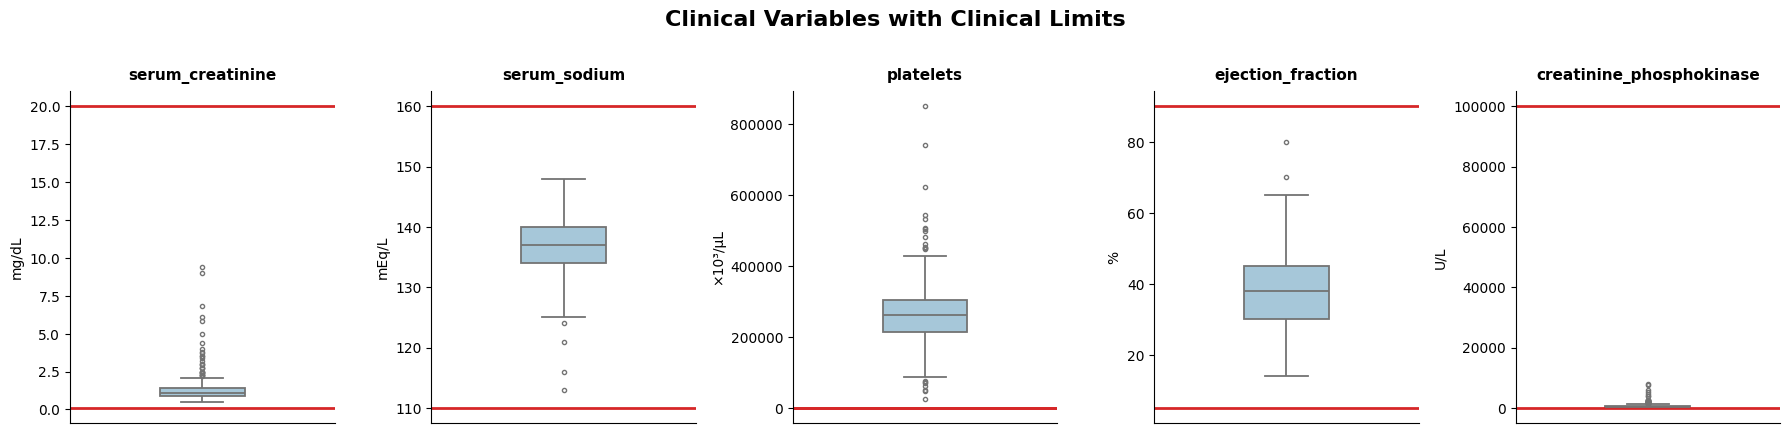

In [16]:
# Clinical imposible values
df_limits = pd.DataFrame({
    "variable": [
        "serum_creatinine",
        "serum_sodium",
        "platelets",
        "ejection_fraction",
        "creatinine_phosphokinase"
    ],
    "clinical_lower": [0.1, 110, 10, 5, 10],
    "clinical_upper": [20, 160, 1000, 90, 100000],
    "units": ["mg/dL", "mEq/L", "×10³/µL", "%", "U/L"]
})


df_limits_plot = df_limits.set_index("variable")
vars_to_plot = df_limits_plot.index.tolist()

plot_grid(
    df=df,
    columns=vars_to_plot,
    plot_func=plot_clinical_boxplot,
    title="Clinical Variables with Clinical Limits",
    n_cols=5,
    figsize=(18, 4.2),
    df_limits_plot=df_limits_plot
)

### Outlier Decision & Clinical Validation — Conclusion

IQR-based detection flags outliers in `creatinine_phosphokinase` (9.7%), `serum_creatinine` (9.7%), and `platelets` (7.0%). However, all 299 observations fall within physiologically plausible limits for every variable. No values exceed the defined clinical bounds (e.g., serum creatinine ≤ 20 mg/dL, ejection fraction between 5–90%, CPK ≤ 100,000 U/L).

**Decision: retain all outliers**: no data entry errors or impossible measurements detected. The statistical outliers flagged in section 2.1.2 are clinically plausible extreme values, not data errors. No observations are removed.

- Extreme `creatinine_phosphokinase` values are expected in rhabdomyolysis or major muscle injury
- High serum creatinine is common in severe renal impairment co-occurring with heart failure
- Removing them would discard clinically meaningful signal and reduce sample size in an already small dataset (n=299)

### 2.1.4 Skewness & Transformations

In [22]:
skew_table=compare_skew(df,numerical_cols)
skew_table

,variable,original_skew,log_skew,abs_original_skew,abs_log_skew,improvement
2,creatinine_phosphokinase,4.463110,0.422715,4.463110,0.422715,4.040395
5,serum_creatinine,4.455996,2.313207,4.455996,2.313207,2.142789
1,age,0.423062,-0.009504,0.423062,0.009504,0.413558
3,ejection_fraction,0.555383,-0.245770,0.555383,0.245770,0.309613
4,platelets,1.462321,-1.284928,1.462321,1.284928,0.177393
0,death_event,0.770349,0.770349,0.770349,0.770349,0.000000
6,serum_sodium,-1.048136,-1.310145,1.048136,1.310145,-0.262009
7,time,0.127803,-1.179780,0.127803,1.179780,-1.051977


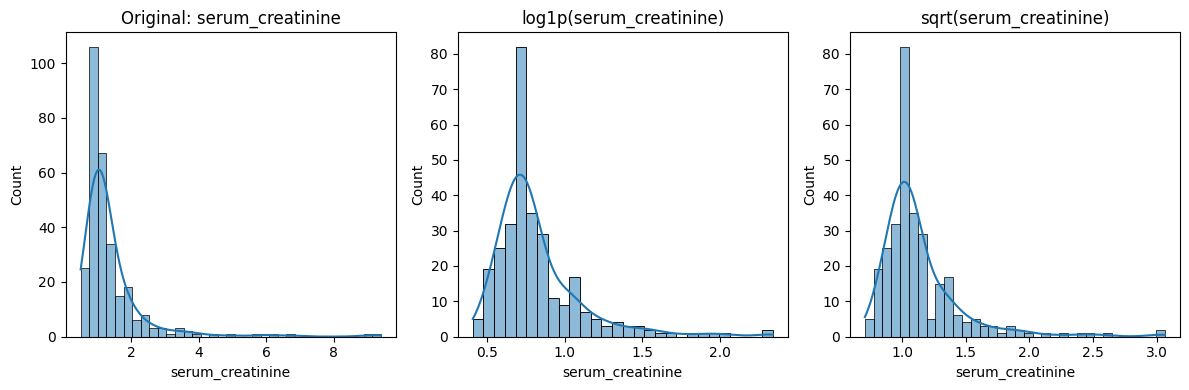

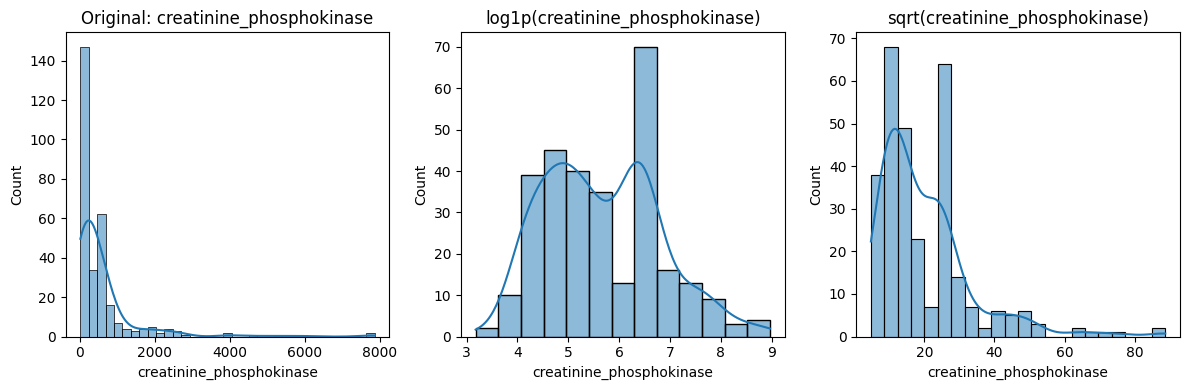

In [24]:
log_candidates = ["serum_creatinine", "creatinine_phosphokinase"]

for col in log_candidates:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Original: {col}")
    
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[1])
    axes[1].set_title(f"log1p({col})")

    sns.histplot(np.sqrt(df[col]), kde=True, ax=axes[2])
    axes[2].set_title(f"sqrt({col})")
    
    plt.tight_layout()
    plt.show()

### Transformation Decision

| Variable | Original Skew | log1p Skew | Decision |
|---|---|---|---|
| `creatinine_phosphokinase` | 4.46 | 0.42 | **Apply log1p** |
| `serum_creatinine` | 4.46 | 2.31 | **Apply log1p** |
| Others | < 1.5 | — | Keep original |

`log1p` transformation will be applied to both variables in the modeling phase (Notebook 03). `sqrt` was also evaluated but `log1p` produces better symmetry for `creatinine_phosphokinase` and comparable results for `serum_creatinine`. The transformation is deferred to the modeling notebook to keep this EDA on raw data.

### 2.1.5 Categorical Variables

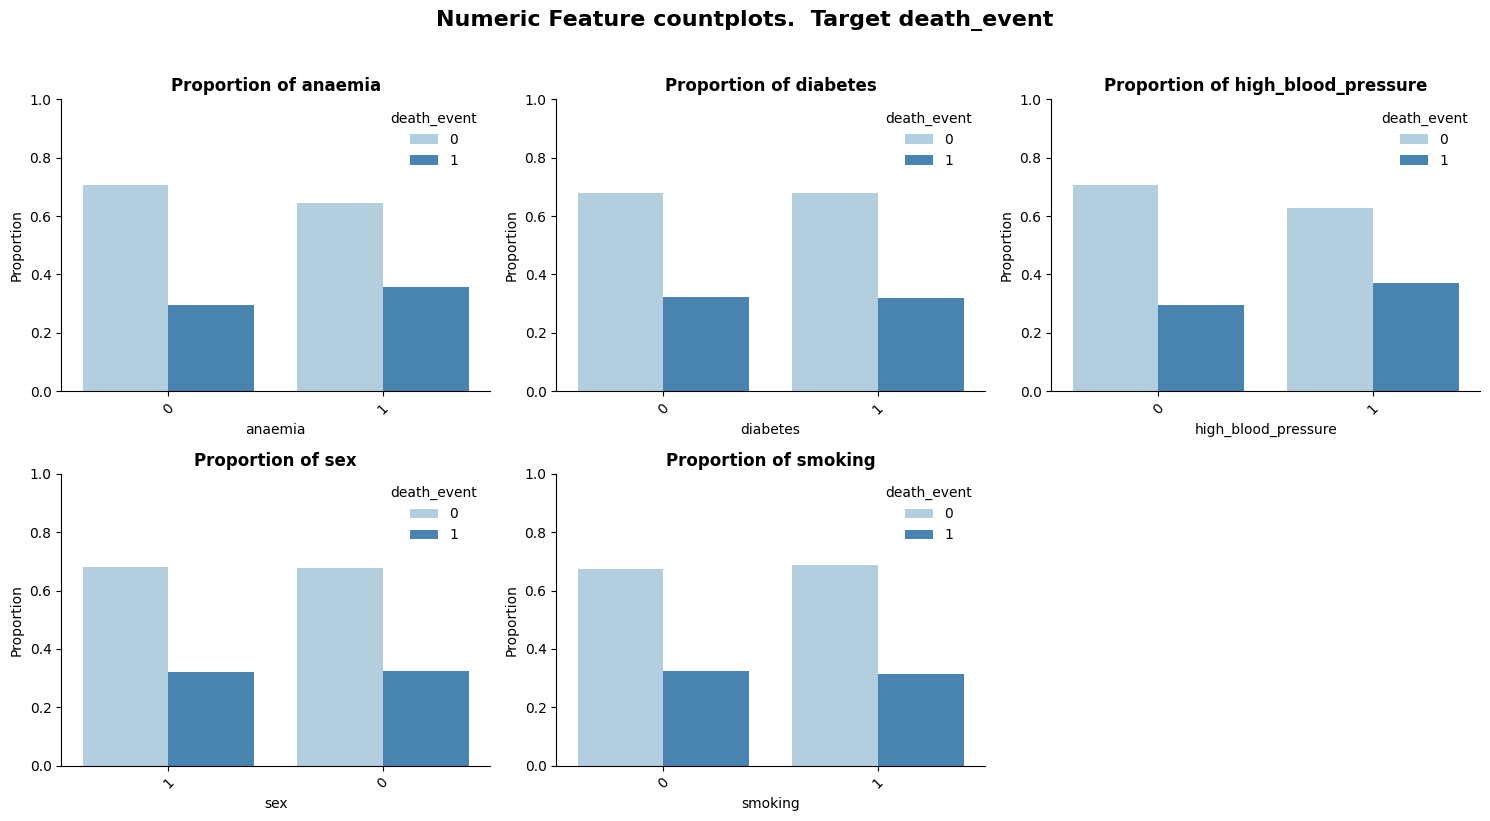

In [18]:
#Get boxplot distribution
plot_grid(
    df=df,
    columns=categorical_cols,
    plot_func= plot_countplot,
    title="Numeric Feature countplots.  Target death_event",
    target = "death_event"
    )

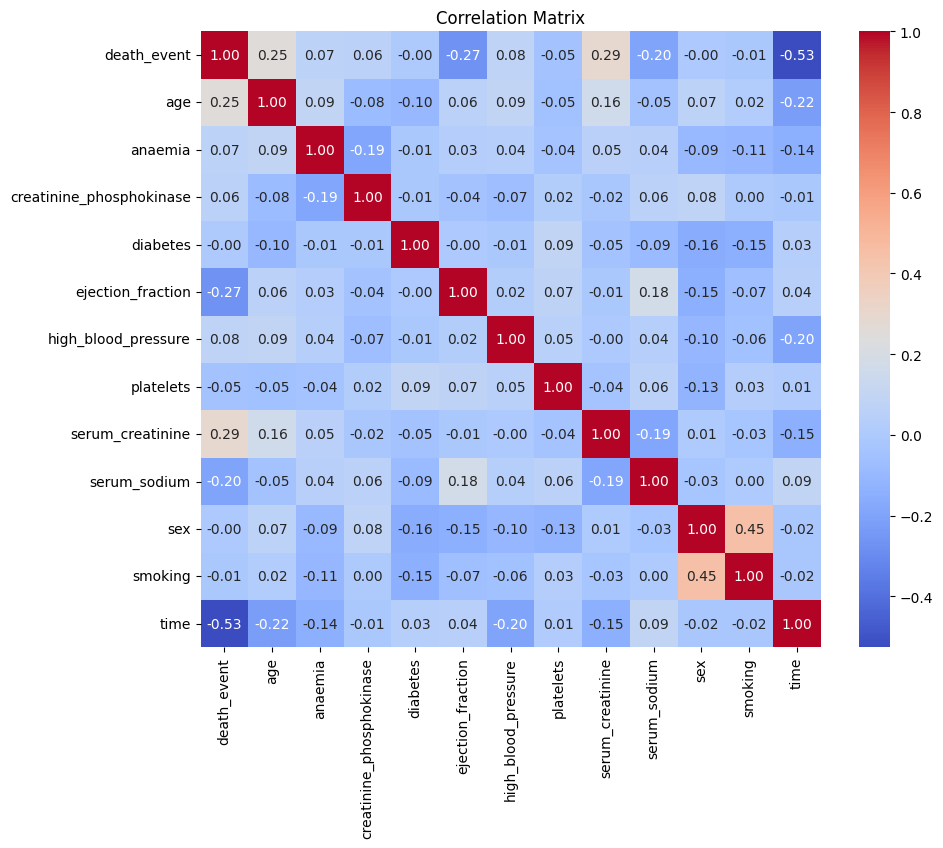

In [19]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

### Observations — Categorical Variables & Correlations

**Categorical variables**: None of the binary features (anaemia, diabetes, high blood pressure, sex, smoking) show a strong visual association with death_event. Differences in mortality rates appear relatively small. Formal statistical tests (chi-square or Fisher’s exact test), to be performed in 02_statistical_inference, will help assess whether these differences are statistically significant.

**Correlation matrix highlights**:
- `time` shows the strongest negative correlation with death_event, with shorter follow-up associated with death. However, this relationship reflects the definition of the variable rather than a true predictive signal, and time will be excluded from modeling due to data leakage.
- `serum_creatinine` shows a moderate positive correlation with the target
- `ejection_fraction` shows a moderate negative correlation with the target
- Low inter-feature correlations overall — no obvious multicollinearity concerns (VIF analysis in 02_statistical_inference will confirm)

## 2.2 Bivariate Distribution

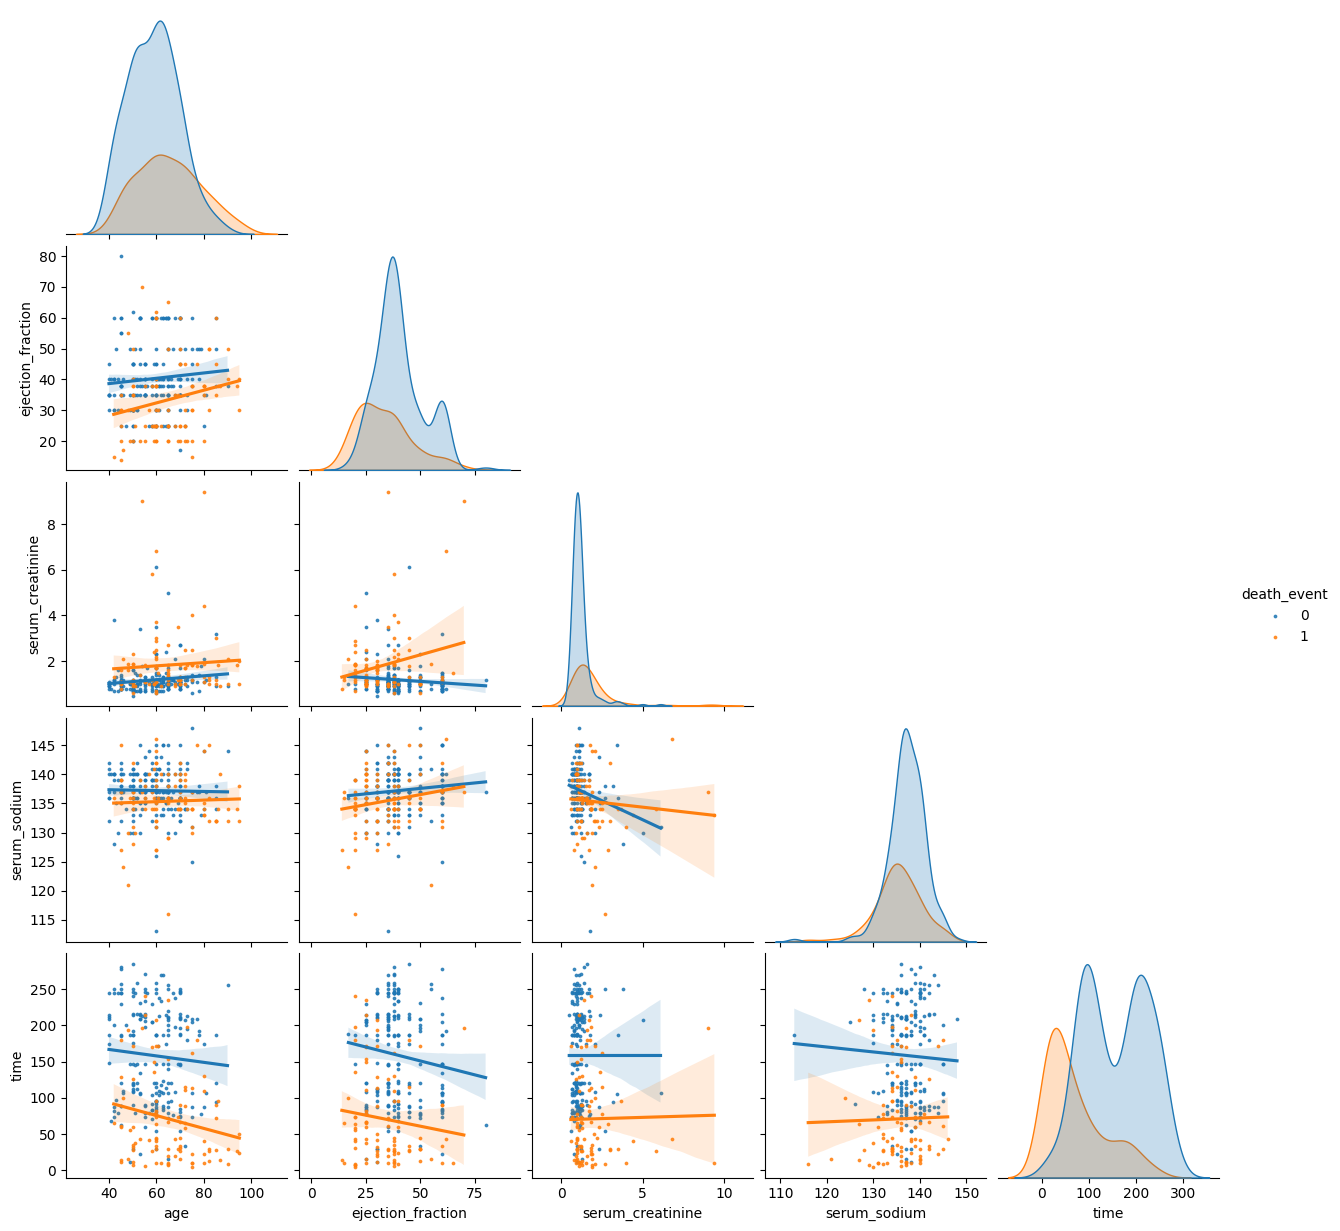

In [24]:
selected_cols = ["age", "ejection_fraction", "serum_creatinine", "serum_sodium", "time", "death_event"]
sns.pairplot(df[selected_cols],
             hue="death_event",
             corner=True,
             kind= 'reg',
             diag_kind= 'kde',
             plot_kws=dict(scatter_kws=dict(s=3)))
plt.show()

### Observations — Bivariate Patterns

The pairplot confirms the most discriminative features visible from the marginal KDE distributions:

- **`ejection_fraction` + `serum_creatinine`**: the combination of low ejection fraction and high creatinine concentrates strongly in the death group. This is consistent with cardiac-renal syndrome in advanced heart failure
- **`age`**: mild separation; older patients trend toward higher mortality
- **`serum_sodium`**: subtle separation; the death group shows slightly lower sodium levels

These visual patterns motivate the feature selection strategy in 03_logistic_regression_model, where backward AIC elimination will formally confirm which variables are retained in the final model.